# Dev Stages across various tasks

Run 4 'developmental profiles' over tasks that vary by:

- **Distance**: how far the object must travel (short / medium / far)
- **Rotation demand**: how much the object must be turned (0° / 90° / 180°)
- **Aspect ratio**: width-to-height ratio of the object (tall-narrow / square / wide-flat)


## Outputs

- **Success rate**: proportion of trials where the agent reached the goal within tolerance
- **Path efficiency**: optimal/actual path length (1 = perfectly direct)
- **Mean timesteps**: trial duration (lower = faster)
- **Gaze switches**: fixation shifts between object and target
- **Movement onset**: steps before the agent starts moving (deliberation time)
- **Stage profile radar**: all six metrics at once, normalised so outer edge = best

In [ ]:
from dataclasses import replace
from html import escape
from pathlib import Path
import sys

from collections import defaultdict
from html import escape

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

import math
from IPython.display import HTML, display

cwd = Path.cwd()

from affordance_matrices import AFFORDANCE_MATRIX_VARIANTS
from model_utils import DevelopmentalParams, TaskConfig
from planning_cascade_model import run_trial
from model_utils import run_simulation, group_results, summarise_group

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## Developmental Stage Profiles

Four profiles to try to capture the major perceptual, attentional, and motor changes across early development. A = youngest, D = most mature

In [ ]:
DEVELOPMENTAL_STAGES = {
    "A": DevelopmentalParams(
        name="A",
        gaze_switch_rate=0.12, fixation_duration_mean=5.0, target_bias=0.20,
        simultaneous_rate=0.03, sampling_rate=0.30, perceptual_noise=0.35,
        location_acuity=0.70, orientation_acuity=0.15, relation_acuity=0.05,
        wm_capacity=2, wm_decay=0.18, wm_unfixated_decay=0.40,
        affordance_coupling=0.25, affordance_noise=0.25, planning_horizon=1,
        motor_noise=0.20, habit_strength=0.78, goal_directed_strength=0.22,
        correction_rate=0.12, correction_delay=2, initiation_threshold=0.15,
    ),
    "B": DevelopmentalParams(
        name="B",
        gaze_switch_rate=0.25, fixation_duration_mean=3.5, target_bias=0.35,
        simultaneous_rate=0.12, sampling_rate=0.45, perceptual_noise=0.28,
        location_acuity=0.85, orientation_acuity=0.30, relation_acuity=0.12,
        wm_capacity=3, wm_decay=0.12, wm_unfixated_decay=0.28,
        affordance_coupling=0.40, affordance_noise=0.22, planning_horizon=2,
        motor_noise=0.22, habit_strength=0.70, goal_directed_strength=0.30,
        correction_rate=0.14, correction_delay=2, initiation_threshold=0.28,
    ),
    "C": DevelopmentalParams(
        name="C",
        gaze_switch_rate=0.40, fixation_duration_mean=2.5, target_bias=0.50,
        simultaneous_rate=0.28, sampling_rate=0.65, perceptual_noise=0.16,
        location_acuity=0.93, orientation_acuity=0.55, relation_acuity=0.30,
        wm_capacity=4, wm_decay=0.08, wm_unfixated_decay=0.18,
        affordance_coupling=0.60, affordance_noise=0.14, planning_horizon=4,
        motor_noise=0.16, habit_strength=0.40, goal_directed_strength=0.60,
        correction_rate=0.22, correction_delay=1, initiation_threshold=0.40,
    ),
    "D": DevelopmentalParams(
        name="D",
        gaze_switch_rate=0.55, fixation_duration_mean=2.0, target_bias=0.60,
        simultaneous_rate=0.50, sampling_rate=0.85, perceptual_noise=0.08,
        location_acuity=0.98, orientation_acuity=0.88, relation_acuity=0.55,
        wm_capacity=5, wm_decay=0.04, wm_unfixated_decay=0.10,
        affordance_coupling=0.85, affordance_noise=0.08, planning_horizon=6,
        motor_noise=0.08, habit_strength=0.10, goal_directed_strength=0.90,
        correction_rate=0.28, correction_delay=0, initiation_threshold=0.45,
    ),
}

STAGE_COLOURS = {"A": "#0584CD", "B": "#E76C1F", "C": "#7C0DC2", "D": "#6A6A6A"}

## Task Battery — Integrated Geometry Variations

Instead of a factorial grid that varies one dimension at a time, the battery
crosses all three geometric factors so that every task is a unique *joint* combination:

| Dimension | Levels |
|-----------|--------|
| Distance | 0.35 / 0.70 / 1.10 units (short / medium / far) |
| Rotation | 0° / 90° / 180° (none / quarter-turn / half-turn) |
| Aspect ratio (width ÷ height) | 0.4 (tall-narrow) / 1.0 (square) / 2.2 (wide-flat) |

3 × 3 × 3 = **27 integrated tasks**, each labelled `d{dist}r{rot}a{aspect}`.

In [ ]:
_DISTANCES   = [0.35, 0.70, 1.10]        # short / medium / far
_ROTATIONS   = [0.0, math.pi/2, math.pi]  # 0° / 90° / 180°
_ASPECTS     = [0.4, 1.0, 2.2]           # tall-narrow / square / wide-flat
_BASE_HEIGHT = 0.4

BATTERY_TASKS = {}
TASK_META     = {}

for d_idx, dist in enumerate(_DISTANCES):
    for r_idx, rot in enumerate(_ROTATIONS):
        for a_idx, aspect in enumerate(_ASPECTS):
            name = f"d{d_idx}r{r_idx}a{a_idx}"
            BATTERY_TASKS[name] = TaskConfig(
                name=name,
                start_x=0.0, start_y=0.0, start_angle=0.0,
                goal_x=dist, goal_y=0.0, goal_angle=rot,
                obj_width=round(aspect * _BASE_HEIGHT, 3),
                obj_height=_BASE_HEIGHT,
                max_timesteps=int(80 + dist * 90),
            )
            # Composite difficulty: mean of three normalised dimension scores
            dist_score  = d_idx / (len(_DISTANCES) - 1)         # 0→1 as distance grows
            rot_score   = r_idx / (len(_ROTATIONS) - 1)         # 0→1 as rotation grows
            shape_score = abs(a_idx - 1) / (len(_ASPECTS) - 1)  # 0 at square, 1 at extremes
            TASK_META[name] = {
                "dist": dist, "rot": rot, "aspect": aspect,
                "dist_idx": d_idx, "rot_idx": r_idx, "aspect_idx": a_idx,
                "difficulty": (dist_score + rot_score + shape_score) / 3,
            }

N_TRIALS = 20
SEED = 42
print(f"Battery: {len(BATTERY_TASKS)} tasks × {len(DEVELOPMENTAL_STAGES)} stages × {N_TRIALS} trials "
      f"= {len(BATTERY_TASKS) * len(DEVELOPMENTAL_STAGES) * N_TRIALS} total runs")
print(f"\nTask dimensions:")
print(f"  Distance:     {_DISTANCES} units")
print(f"  Rotation:     {[f'{math.degrees(r):.0f}°' for r in _ROTATIONS]}")
print(f"  Aspect ratio: {_ASPECTS}  (width / height, base height = {_BASE_HEIGHT})")

## Run Simulations

Loops over every (stage, task, trial) combination and returns
a flat list of `TrialResult` objects.

In [5]:
results = run_simulation(DEVELOPMENTAL_STAGES, BATTERY_TASKS, n_trials=N_TRIALS, seed=SEED)
groups = group_results(results)
summary = [
    summarise_group(stage, task, trials)
    for (stage, task), trials in groups.items()
]
print(f"Finished. {len(results)} trial results across {len(groups)} (stage, task) groups.")

Finished. 2160 trial results across 108 (stage, task) groups.


## Stage Performance Averages

Each metric averaged across all 27 tasks in the battery.
This gives one representative score per developmental stage.

In [6]:
def format_cell(value):
    if isinstance(value, float):
        return f"{value:.3f}"
    return escape(str(value))

def rows_to_html(rows, columns):
    header = "".join(f"<th>{escape(c)}</th>" for c in columns)
    body = "".join(
        f"<tr>{''.join(f'<td>{format_cell(row[c])}</td>' for c in columns)}</tr>"
        for row in rows
    )
    style = "border-collapse:collapse;font-family:sans-serif;font-size:12px;"
    cell_style = "th,td{border:1px solid #ddd;padding:3px 7px;text-align:right}th:first-child,td:first-child{text-align:left}"
    return f"<style>{cell_style}</style><table style='{style}'><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"

_METRICS = [
    "success_rate", "mean_efficiency", "mean_timesteps",
    "mean_movement_onset", "mean_gaze_switches",
    "mean_target_fixation_pct", "mean_object_fixation_pct",
    "mean_pos_error", "mean_angle_error",
]

_stage_sums = defaultdict(lambda: defaultdict(list))
for row in summary:
    for m in _METRICS:
        _stage_sums[row["stage"]][m].append(row[m])

STAGE_AVG = {
    s: {m: float(np.mean(vals)) for m, vals in mets.items()}
    for s, mets in _stage_sums.items()
}

display_rows = [{"Stage": s, **{m: STAGE_AVG[s][m] for m in _METRICS}}
                for s in DEVELOPMENTAL_STAGES]
display(HTML(rows_to_html(display_rows, ["Stage"] + _METRICS)))

Stage,success_rate,mean_efficiency,mean_timesteps,mean_movement_onset,mean_gaze_switches,mean_target_fixation_pct,mean_object_fixation_pct,mean_pos_error,mean_angle_error
A,0.244,0.404,125.470,4.250,14.487,0.556,0.444,2.273,1.092
B,0.276,0.436,123.972,10.550,26.587,0.607,0.393,1.708,0.954
C,0.820,0.827,81.724,7.950,27.409,0.669,0.331,0.210,0.129
D,1.000,1.000,57.417,6.500,27.928,0.813,0.187,0.034,0.060


## Dev Stage Profile Radar Chart

Each axis is one performance dimension, normalised so that the outer edge always
represents best performance. The polygon area gives an at-a-glance picture of overall competence at each
stage. All values averaged across the full 27-task battery.

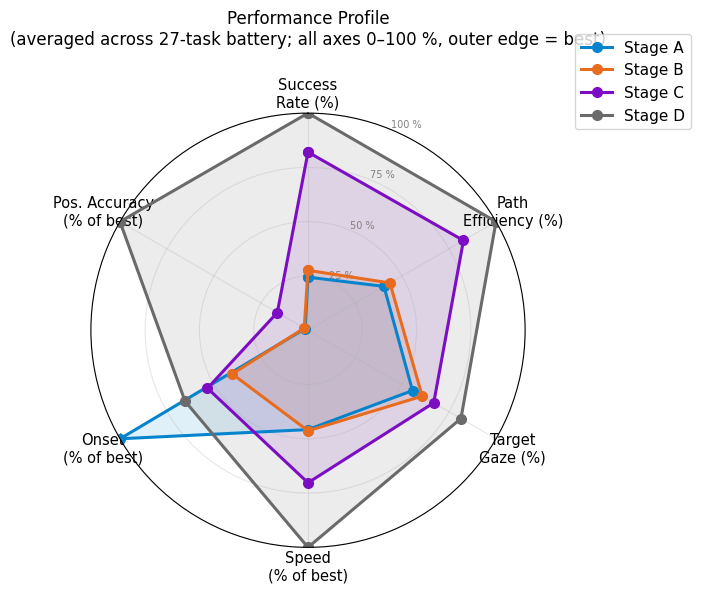

In [11]:
def plot_radar(stage_avg, stage_names, stage_colours):
    """Spider chart: one polygon per stage, six performance axes on a shared
    absolute 0-100 % scale.
    """
    # (label, metric key, kind)
    #   "prop" -> stored as 0-1 proportion, multiply by 100
    #   "pct"  -> already stored as a percentage
    #   "inv"  -> lower is better; plot best/value x 100
    axes_spec = [
        ("Success\nRate (%)",          "success_rate",             "prop"),
        ("Path\nEfficiency (%)",       "mean_efficiency",          "prop"),
        ("Target\nGaze (%)",           "mean_target_fixation_pct", "prop"),
        ("Speed\n(% of best)",         "mean_timesteps",           "inv"),
        ("Onset\n(% of best)",         "mean_movement_onset",      "inv"),
        ("Pos. Accuracy\n(% of best)", "mean_pos_error",           "inv"),
    ]
    labels = [a[0] for a in axes_spec]
    n = len(labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    raw = {s: [stage_avg[s][m] for _, m, _ in axes_spec] for s in stage_names}
    # best (minimum) value per lower-is-better axis, for the "% of best" scaling
    col_best = [min(raw[s][i] for s in stage_names) for i in range(n)]

    def to_pct(val, i):
        kind = axes_spec[i][2]
        if kind == "prop":
            return val * 100.0
        if kind == "pct":
            return val
        # "inv": percentage of best-stage performance (100 % = best)
        return (col_best[i] / val) * 100.0 if val > 0 else 100.0

    scored = {}
    for s in stage_names:
        v = [to_pct(raw[s][i], i) for i in range(n)]
        scored[s] = v + v[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10.5)
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75, 100])
    ax.set_yticklabels(["25 %", "50 %", "75 %", "100 %"], fontsize=7, color="grey")
    ax.grid(alpha=0.3)

    for s in stage_names:
        c = stage_colours[s]
        ax.plot(angles, scored[s], "o-", color=c, lw=2.2, markersize=7, label=f"Stage {s}")
        ax.fill(angles, scored[s], alpha=0.12, color=c)

    ax.legend(loc="upper right", bbox_to_anchor=(1.40, 1.20), fontsize=11)
    ax.set_title(
        f"Performance Profile\n"
        f"(averaged across {len(BATTERY_TASKS)}-task battery; all axes 0\u2013100 %, outer edge = best)",
        pad=24, fontsize=12,
    )
    plt.tight_layout()
    plt.show()

plot_radar(STAGE_AVG, list(DEVELOPMENTAL_STAGES), STAGE_COLOURS)

## Success Rate Distribution Across the Battery

Violin plots show the full spread of success rates per task

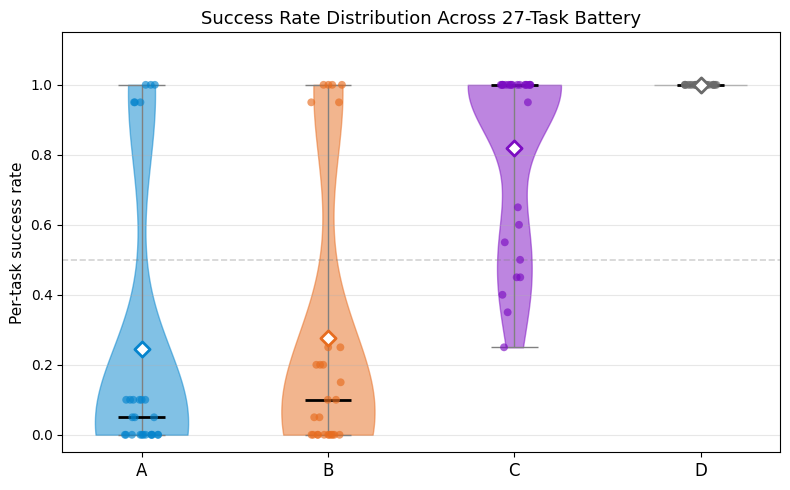

In [8]:
def plot_success_distributions(summary, stage_names, stage_colours, n_tasks):
    stage_data = {s: [] for s in stage_names}
    for row in summary:
        stage_data[row["stage"]].append(row["success_rate"])

    fig, ax = plt.subplots(figsize=(8, 5))
    positions = list(range(len(stage_names)))

    parts = ax.violinplot(
        [stage_data[s] for s in stage_names],
        positions=positions, showmedians=True, showextrema=True,
    )
    for pc, s in zip(parts["bodies"], stage_names):
        pc.set_facecolor(stage_colours[s])
        pc.set_edgecolor(stage_colours[s])
        pc.set_alpha(0.50)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(2.0)
    for key in ("cmins", "cmaxes", "cbars"):
        parts[key].set_color("grey")
        parts[key].set_linewidth(1.0)

    rng = np.random.default_rng(7)
    for i, s in enumerate(stage_names):
        jitter = rng.uniform(-0.09, 0.09, len(stage_data[s]))
        ax.scatter(i + jitter, stage_data[s], alpha=0.65, s=32,
                   color=stage_colours[s], edgecolors="none", zorder=3)
        mean_val = np.mean(stage_data[s])
        ax.scatter(i, mean_val, marker="D", s=60, color="white",
                   edgecolors=stage_colours[s], linewidths=2, zorder=5)

    ax.set_xticks(positions)
    ax.set_xticklabels([f"{s}" for s in stage_names], fontsize=12)
    ax.set_ylabel("Per-task success rate", fontsize=11)
    ax.set_ylim(-0.05, 1.15)
    ax.set_title(f"Success Rate Distribution Across {n_tasks}-Task Battery", fontsize=13)
    ax.axhline(0.5, ls="--", color="grey", alpha=0.35, lw=1.2)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_success_distributions(summary, list(DEVELOPMENTAL_STAGES), STAGE_COLOURS, len(BATTERY_TASKS))

## Effect of Each Task Dimension

Success rate averaged along each geometric dimension in turn (collapsing across
the other two). This shows which factor (distance, rotation, or shape) most
strongly challenges each age group, and how each stage degrades as that factor
increases.

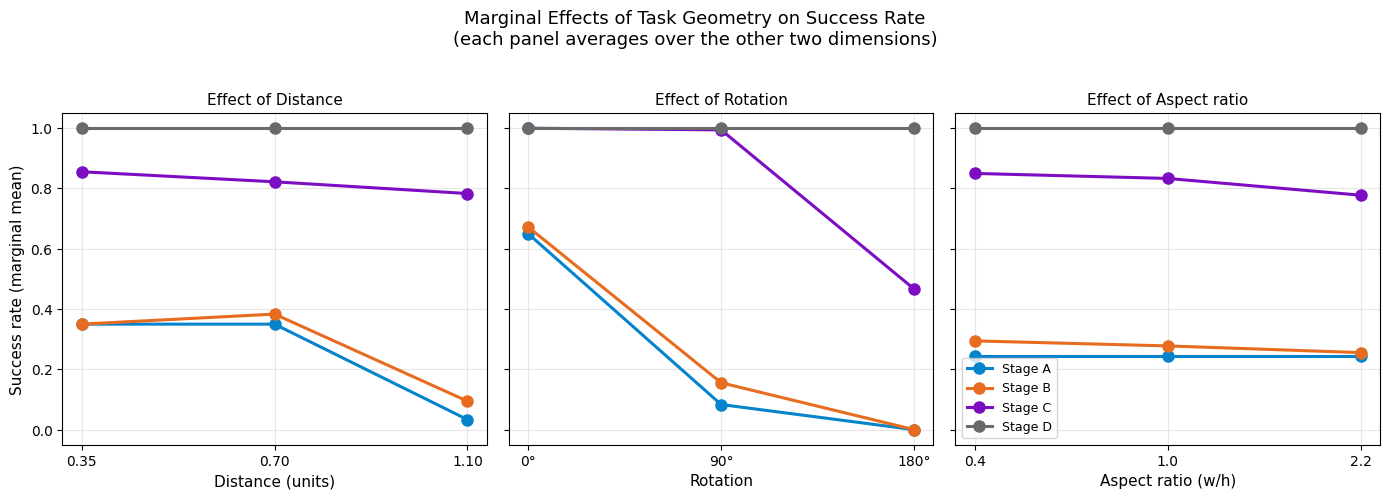

In [9]:
def plot_marginal_effects(summary, task_meta, stage_names, stage_colours):
    dims = [
        ("dist_idx",   "Distance (units)",   [f"{d:.2f}" for d in _DISTANCES]),
        ("rot_idx",    "Rotation",           [f"{math.degrees(r):.0f}°" for r in _ROTATIONS]),
        ("aspect_idx", "Aspect ratio (w/h)", [str(a) for a in _ASPECTS]),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
    for ax, (dim_key, dim_label, tick_labels) in zip(axes, dims):
        n_levels = len(tick_labels)
        for s in stage_names:
            stage_rows = {row["task"]: row["success_rate"]
                          for row in summary if row["stage"] == s}
            means = []
            for lvl in range(n_levels):
                vals = [stage_rows[tn] for tn, meta in task_meta.items()
                        if meta[dim_key] == lvl and tn in stage_rows]
                means.append(float(np.mean(vals)) if vals else float("nan"))
            ax.plot(range(n_levels), means, "o-", color=stage_colours[s],
                    lw=2.2, markersize=8, label=f"Stage {s}")
        ax.set_xticks(range(n_levels))
        ax.set_xticklabels(tick_labels, fontsize=10)
        ax.set_xlabel(dim_label, fontsize=11)
        ax.set_title(f"Effect of {dim_label.split('(')[0].strip()}", fontsize=11)
        ax.grid(alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
    axes[0].set_ylabel("Success rate (marginal mean)", fontsize=11)
    axes[-1].legend(fontsize=9)
    plt.suptitle("Marginal Effects of Task Geometry on Success Rate\n"
                 "(each panel averages over the other two dimensions)",
                 fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

plot_marginal_effects(summary, TASK_META, list(DEVELOPMENTAL_STAGES), STAGE_COLOURS)